# Plot time series for the year at some key stations

In [1]:
import numpy as np 
import sys
import pandas as pd
import datetime as datetime    
import xarray as xr 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates 
import matplotlib as mpl
import re 
from scipy import signal #for filtering
import cmocean
import matplotlib.dates as mdates
print("Modules imported")

Modules imported


In [2]:
import re 
file="/expanse/lustre/scratch/jisrael/temp_project/run_schism/run_28/station.in"
station_id =[]
with open(file) as f:
    f.readline()
    for station in range(int(f.readline())):
        line = f.readline()
        if '!' in line:
            station_id.append(line.split('!')[-1])
        else:
            station_id.append(None)
# print(station_id)

print(len(station_id))

stations = []
for sublist in station_id:
    match = re.search(r'"(.*?)"', sublist)
    if match:
        stations.append(match.group(1).strip())
    else :
        stations.append(sublist.replace("\n", "").strip())
print(len(set(stations)))


for i, station in enumerate(stations):
    print("%d == %s" % (i+1,station))

408
379
1 == San Joaquin at Antioch
2 == Mokelumne River at Benson's Ferry
3 == Cache Slough
4 == Cache Creek at Yolo
5 == Old River at Coney Island
6 == Clifton Court
7 == Discovery Bay at Indian Slough
8 == Doughty Cut above Grant Line Canal
9 == Sacramento River at Emmaton
10 == Sacramento River at Emmaton
11 == emm upper Emmaton
12 == emm lower Emmaton
13 == Farrar Park
14 == Grant Line Canal at Tracy Rd Bridge
15 == Green's Landing
16 == Harvey O Banks PP
17 == Holland Tract
18 == Harvey O Banks PP
19 == CCWD Old River near Discovery Bay
20 == CCWD Rock Slough PP
21 == Italian Slough Headwater near Byron
22 == Jersey Point
23 == Sacramento River at Mallard Island
24 == Sacramento River at Mallard Island
25 == Middle River at Howard Rd Bridge
26 == San Joaquin at Mossdale Bridge
27 == Middle River at Tracy Blvd
28 == Old River Barrier near DMC (Above)
29 == Old River below Dam
30 == Old River at Bacon Island
31 == Old River at Head
32 == Old River at Byron
33 == Prisoners Point
34 

In [3]:
#swap out the old file paths for the new savio runs 
#file27='/expanse/lustre/scratch/jisrael/temp_project/run_schism/run_27/station_files/staout_6_filt.csv'
file27='/expanse/lustre/scratch/jisrael/temp_project/run_schism/run_27/station_files/run_27_salinity_padded_filt.csv'
file28='/expanse/lustre/scratch/jisrael/temp_project/run_schism/savio_output/run_31DCP/staout_6_filt.csv'
file29='/expanse/lustre/scratch/jisrael/temp_project/run_schism/savio_output/run_30cor/staout_6_filt.csv'
# file28='/expanse/lustre/scratch/jisrael/temp_project/run_schism/run_28/outputs_bc_all/staout_6_filt.csv'
# file29='/expanse/lustre/scratch/jisrael/temp_project/run_schism/run_29/outputs_bc_all/staout_6_filt.csv'
file30='/expanse/lustre/scratch/jisrael/temp_project/run_schism/run_30/outputs/staout_6_filt.csv'

In [4]:
#load the filtered station data
dtformat = '%Y-%m-%d %H:%M:%S'
run27=pd.read_csv(file27)
run27['datetime']=pd.to_datetime(run27['time'],format=dtformat)
run27.set_index("datetime",inplace=True)
run28=pd.read_csv(file28)
run28['datetime']=pd.to_datetime(run28['time'],format=dtformat)
run28.set_index("datetime",inplace=True)
run29=pd.read_csv(file29)
run29['datetime']=pd.to_datetime(run29['time'],format=dtformat)
run29.set_index("datetime",inplace=True)
run30=pd.read_csv(file30)
run30['datetime']=pd.to_datetime(run30['time'],format=dtformat)
run30.set_index("datetime",inplace=True)

/scratch/jisrael/job_53727272/ipykernel_1768782/1785802375.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  run27['datetime']=pd.to_datetime(run27['time'],format=dtformat)
/scratch/jisrael/job_53727272/ipykernel_1768782/1785802375.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  run28['datetime']=pd.to_datetime(run28['time'],format=dtformat)
/scratch/jisrael/job_53727272/ipykernel_1768782/1785802375.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, 

In [5]:
run27

,time,1,2,3,4,5,6,7,8,9,...,399,400,401,402,403,404,405,406,407,408
datetime,,,,,,,,,,,,,,,,,,,,,
2018-08-27 20:00:00,2018-08-27 20:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-08-27 20:15:00,2018-08-27 20:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-08-27 20:30:00,2018-08-27 20:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-08-27 20:45:00,2018-08-27 20:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-08-27 21:00:00,2018-08-27 21:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-09-30 23:00:00,2021-09-30 23:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-09-30 23:15:00,2021-09-30 23:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-09-30 23:30:00,2021-09-30 23:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


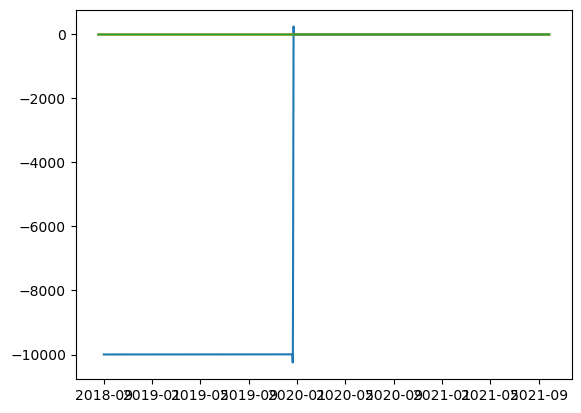

In [7]:
fig, ax = plt.subplots()
ax.plot(run27['408'])
ax.plot(run28['408'])
ax.plot(run29['408'])


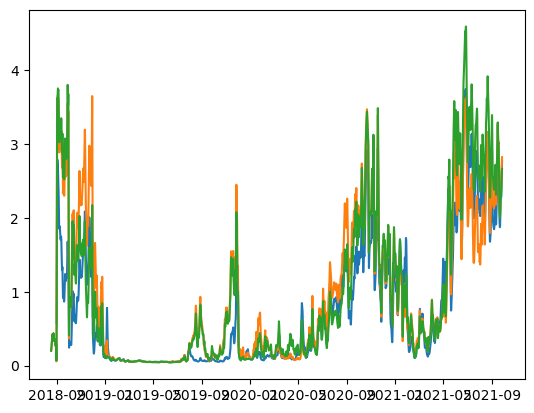

In [8]:
fig, ax = plt.subplots()
ax.plot(run27['10'])
ax.plot(run28['10'])
ax.plot(run29['10'])

# make plots for the water year for the 3 runs at 6 stations

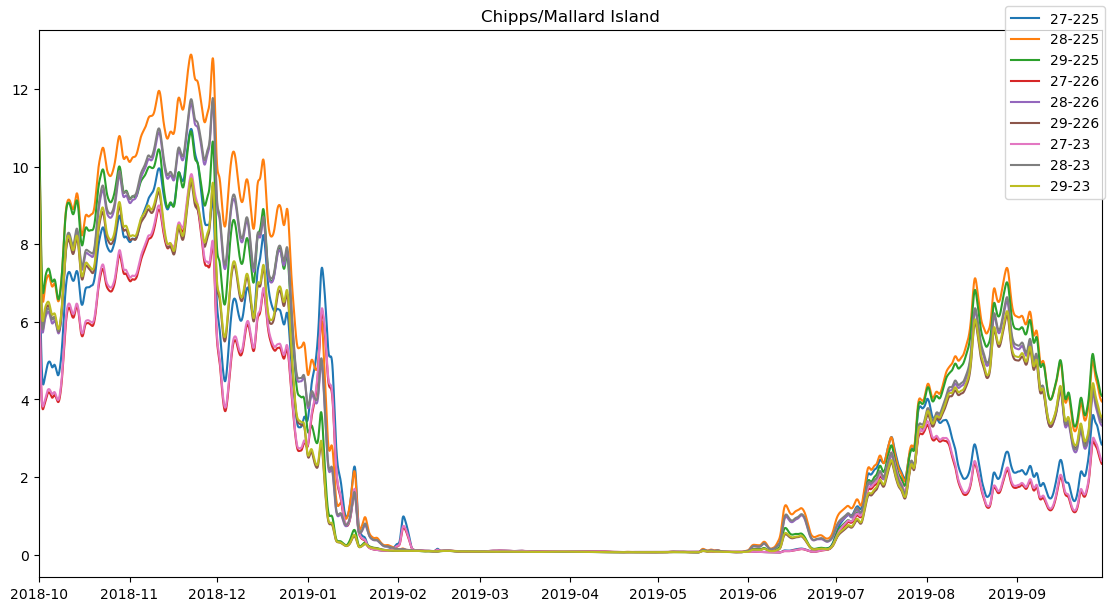

In [9]:
#chipps island: 23, 226 and 225, 225 is higher
fig, ax = plt.subplots(layout='constrained',figsize=[11,6])
ax.plot(run27['225'],label='27-225')
ax.plot(run28['225'],label='28-225')
ax.plot(run29['225'],label='29-225')

ax.plot(run27['226'],label='27-226')
ax.plot(run28['226'],label='28-226')
ax.plot(run29['226'],label='29-226')

ax.plot(run27['23'],label='27-23')
ax.plot(run28['23'],label='28-23')
ax.plot(run29['23'],label='29-23')
ax.set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
ax.set_title('Chipps/Mallard Island')
fig.legend()

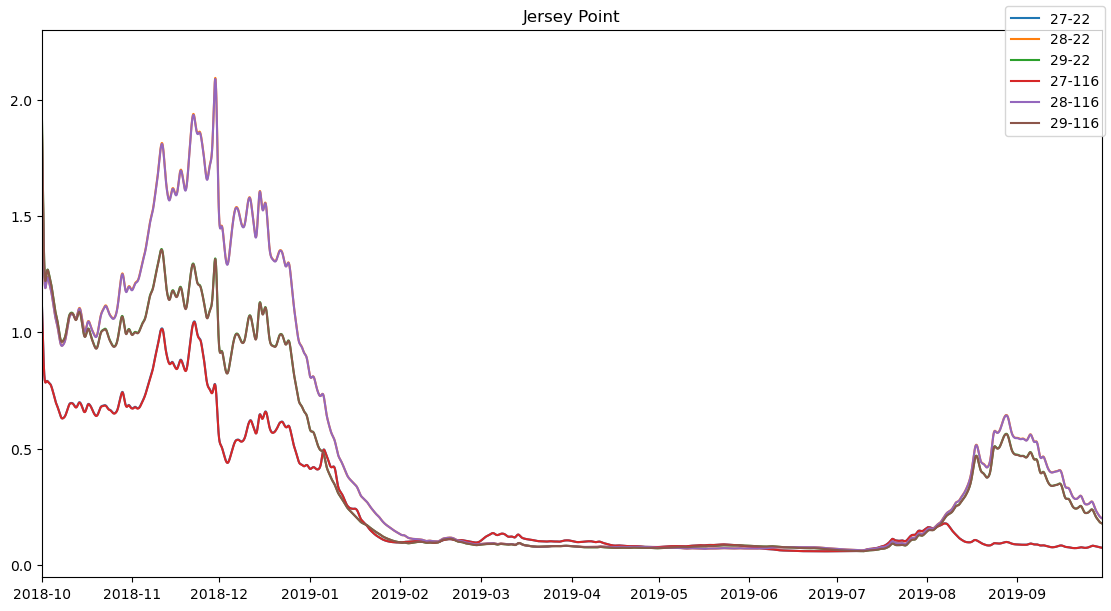

In [10]:
#Jersey Point: 22 and 116, these are the same
fig, ax = plt.subplots(layout='constrained',figsize=[11,6])
ax.plot(run27['22'],label='27-22')
ax.plot(run28['22'],label='28-22')
ax.plot(run29['22'],label='29-22')

ax.plot(run27['116'],label='27-116')
ax.plot(run28['116'],label='28-116')
ax.plot(run29['116'],label='29-116')
ax.set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
ax.set_title('Jersey Point')
fig.legend()
plt.show()

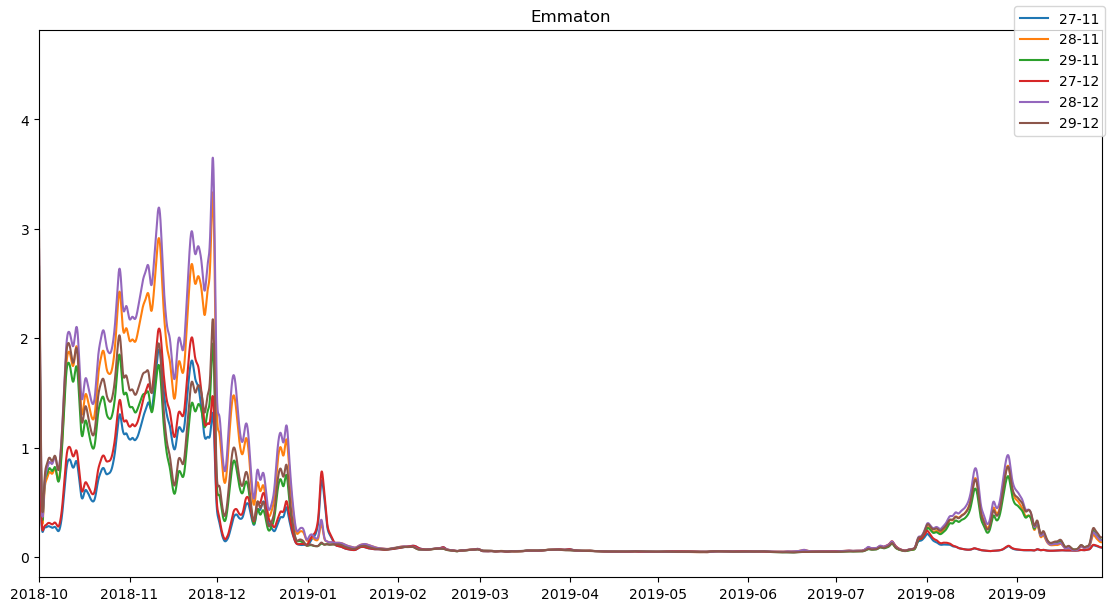

In [11]:
#Emmaton: 11 and 12, 12 is higher 
fig, ax = plt.subplots(layout='constrained',figsize=[11,6])
ax.plot(run27['11'],label='27-11')
ax.plot(run28['11'],label='28-11')
ax.plot(run29['11'],label='29-11')

ax.plot(run27['12'],label='27-12')
ax.plot(run28['12'],label='28-12')
ax.plot(run29['12'],label='29-12')
ax.set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
ax.set_title('Emmaton')
fig.legend()
plt.show()

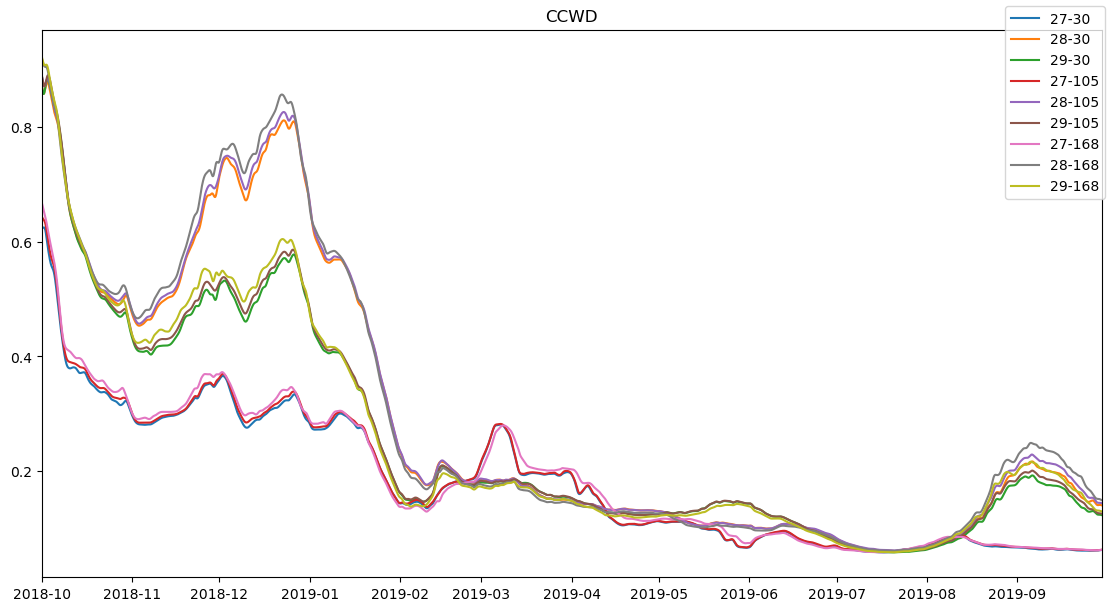

In [12]:
#CCWD: 30, 105, 168, 168 is highest, then 105, then 30
fig, ax = plt.subplots(layout='constrained',figsize=[11,6])
ax.plot(run27['30'],label='27-30')
ax.plot(run28['30'],label='28-30')
ax.plot(run29['30'],label='29-30')

ax.plot(run27['105'],label='27-105')
ax.plot(run28['105'],label='28-105')
ax.plot(run29['105'],label='29-105')

ax.plot(run27['168'],label='27-168')
ax.plot(run28['168'],label='28-168')
ax.plot(run29['168'],label='29-168')
ax.set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
ax.set_title('CCWD')
fig.legend()
plt.show()

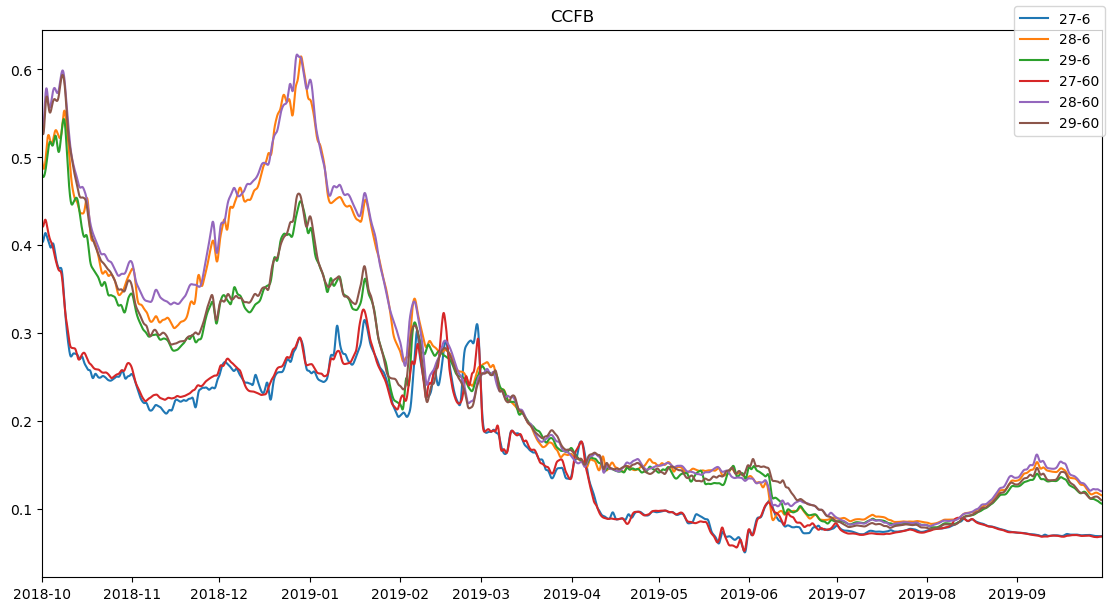

In [13]:
#CCFB: 30, 105, 168, 168 is highest, then 105, then 30
fig, ax = plt.subplots(layout='constrained',figsize=[11,6])
ax.plot(run27['6'],label='27-6')
ax.plot(run28['6'],label='28-6')
ax.plot(run29['6'],label='29-6')

ax.plot(run27['60'],label='27-60')
ax.plot(run28['60'],label='28-60')
ax.plot(run29['60'],label='29-60')

ax.set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
ax.set_title('CCFB')
fig.legend()
plt.show()

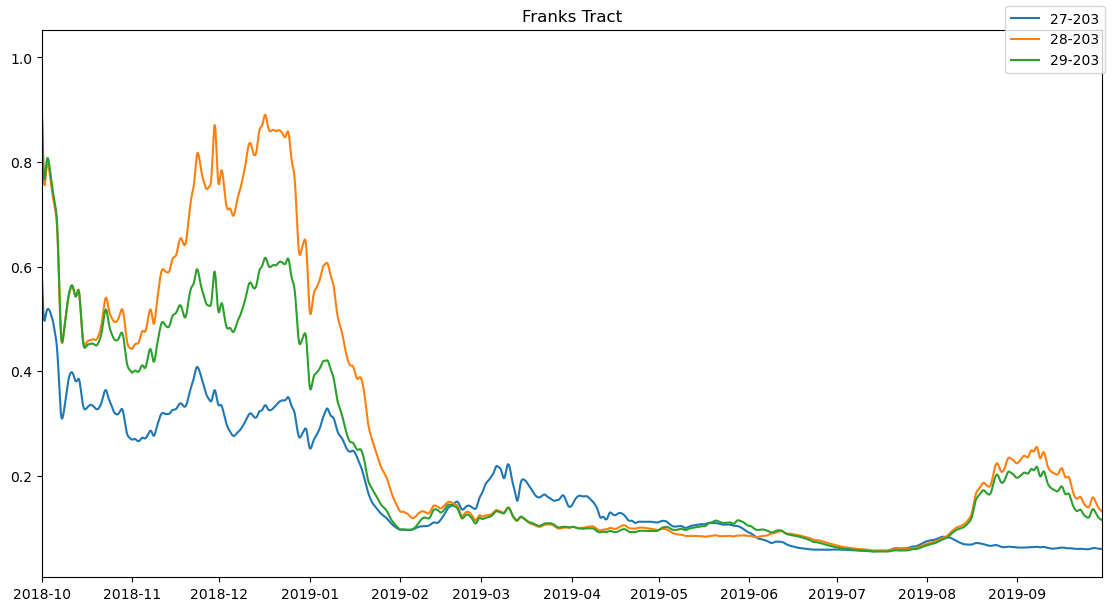

In [14]:
#Franks tract
fig, ax = plt.subplots(layout='constrained',figsize=[11,6])
ax.plot(run27['203'],label='27-203')
ax.plot(run28['203'],label='28-203')
ax.plot(run29['203'],label='29-203')

ax.set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
ax.set_title('Franks Tract')
fig.legend()
plt.show()

# Tile 6 plots

In [15]:
# import matplotlib.dates as mdates

(0, 0)
(0, 1)
(1, 0)
(1, 1)
(2, 0)
(2, 1)


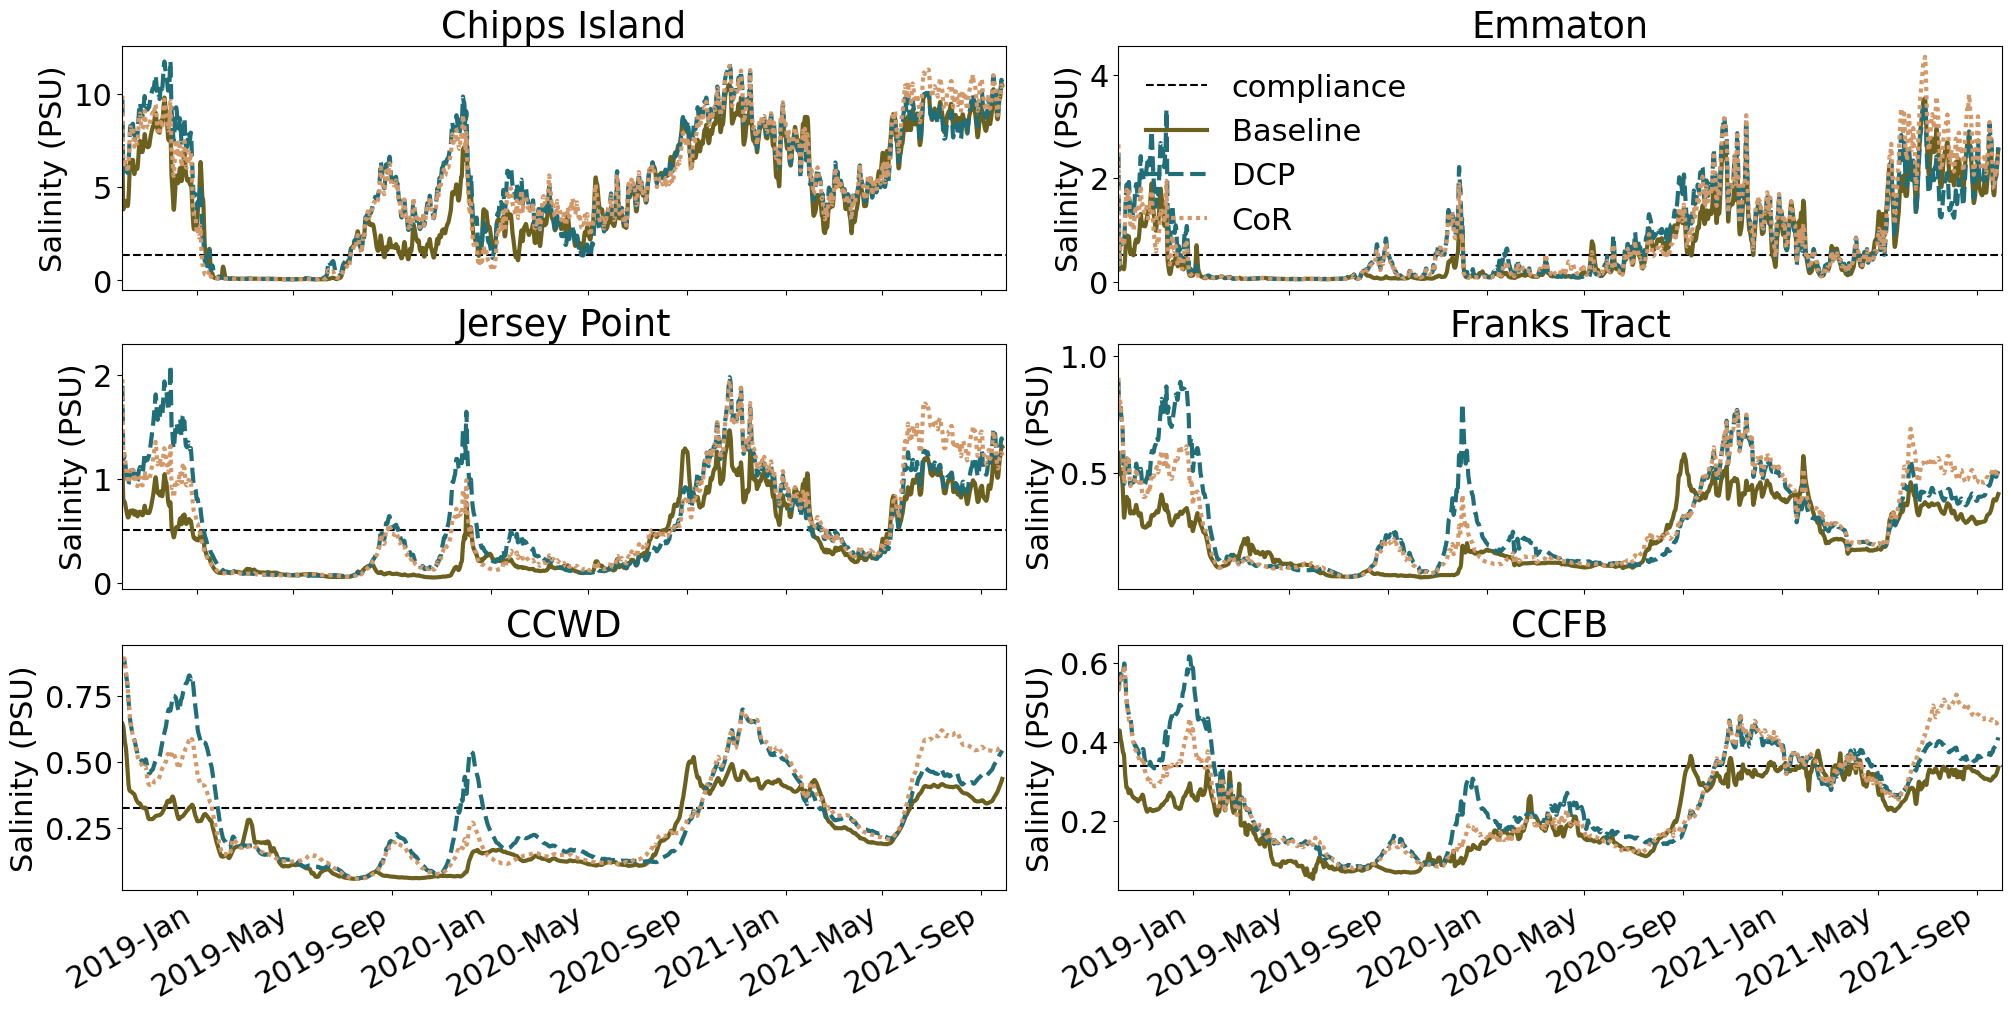

In [19]:
#station_indices=[226,22,12,168,6,203] 
#from Lily:
station_indices=[23,9,22,203,105,60]
fig, ax = plt.subplots(3,2,figsize=(20,10),sharex=True,layout='constrained',label='compliance')
mpl.rcParams.update({'font.size': 22})
# ax.grid(alpha=0.5)
for idx in station_indices:
    if idx == 23:
        s=(0,0)
        tstring='Chipps Island'
        #ax[s].hlines(y=1.3775, xmin=pd.to_datetime("2019-2-1"), xmax=pd.to_datetime("2019-6-1"),color='k',linestyle='--',label='compliance')
        ax[s].hlines(y=1.3775, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2021-10-2"),color='k',linestyle='--',label='compliance')
    if idx == 9:
        s=(0,1)
        tstring='Emmaton'
        #ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2019-4-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
        ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2021-10-2"),color='k',linestyle='--',label='compliance')
    if idx == 22:
        s=(1,0)
        tstring='Jersey Point'
        #ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2019-4-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
        ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2021-10-2"),color='k',linestyle='--',label='compliance')
    if idx == 203:
        s=(1,1)
        tstring='Franks Tract'
    if idx == 105:
        s=(2,0)
        tstring='CCWD'
        ax[s].hlines(y=0.3255, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2021-10-2"),color='k',linestyle='--',label='compliance')
    if idx == 60:
        s=(2,1)
        tstring='CCFB'
        ax[s].hlines(y=0.3387, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2021-10-2"),color='k',linestyle='--',label='compliance')
    
    print(s)
    values1 = run27[str(idx)]
    values2 = run28[str(idx)]
    values3 = run29[str(idx)]
       
    ax[s].plot(values1, label = 'Baseline', linewidth=3, alpha =1, color=cmocean.cm.tarn(1/6))
    ax[s].plot(values2, label = 'DCP', linewidth=3, alpha =1,linestyle='--', color=cmocean.cm.tarn(10/12))
    ax[s].plot(values3, label = 'CoR', linewidth=3, alpha =1,linestyle=(0,(1,1)), color=cmocean.cm.tarn(2/6))
    #ax[s].set_title(stations[idx-1]) #this list is zero indexed
    ax[s].set_title(tstring)
    #ax[s].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
    ax[s].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2021-10-1"))
    ax[s].set_ylabel('Salinity (PSU)')
    # Rotates and right-aligns the x labels so they don't crowd each other.

    
#ax.plot(data1.time,np.ones_like(values1)*std,linewidth=2, alpha =0.7,linestyle='--',color='k',label='Compliance')

#leg = ax.legend()
#print(ax)
#ax.set_xlim(data1.time.iloc[52000], data3.time.iloc[-1]) #July 1 to end
# ax.grid(which='major', color='b', linestyle='-')
#ax.set_title("Salinity from baroclinic run")
#ax[0,1].xaxis.set_major_formatter(mdates.DateFormatter('%b-%d-%Y'))
ax[0,1].legend(frameon=False)
ax[2,0].xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax[2,0].xaxis.get_major_locator()))
ax[2,0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
    # Rotates and right-aligns the x labels so they don't crowd each other.
for label in ax[2,0].get_xticklabels(which='major'):
    label.set(rotation=30, horizontalalignment='right')
ax[2,1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax[2,1].xaxis.get_major_locator()))
ax[2,1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
    # Rotates and right-aligns the x labels so they don't crowd each other.
for label in ax[2,1].get_xticklabels(which='major'):
    label.set(rotation=30, horizontalalignment='right')

plt.show()
fig.savefig('./figures/2026_08_23_six_stations_timeseries_3yrs.png')

In [20]:
# what is the saltiest day at each station?
#station_indices=[226,22,12,168,6,203] 
#from Lily:
station_indices=[23,9,22,203,105,60]
# fig, ax = plt.subplots(3,2,figsize=(20,10),sharex=True,layout='constrained',label='compliance')
# mpl.rcParams.update({'font.size': 22})
# # ax.grid(alpha=0.5)
for idx in station_indices:
    if idx == 23:
        s=(0,0)
        tstring='Chipps Island'
        ax[s].hlines(y=1.3775, xmin=pd.to_datetime("2019-2-1"), xmax=pd.to_datetime("2019-6-1"),color='k',linestyle='--',label='compliance')
    if idx == 9:
        s=(0,1)
        tstring='Emmaton'
        ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2019-4-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
    if idx == 22:
        s=(1,0)
        tstring='Jersey Point'
        ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2019-4-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
    if idx == 203:
        s=(1,1)
        tstring='Franks Tract'
    if idx == 105:
        s=(2,0)
        tstring='CCWD'
        ax[s].hlines(y=0.3255, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--',label='compliance')
    if idx == 60:
        s=(2,1)
        tstring='CCFB'
        ax[s].hlines(y=0.3387, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--',label='compliance')
    
    print(s)
    values1 = run27[str(idx)]
    values2 = run28[str(idx)]
    values3 = run29[str(idx)]

    #what is the max salinity in the range set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
    maxs=values1[pd.to_datetime("2018-10-1"):pd.to_datetime("2021-10-1")].max()
    maxdate=values1[pd.to_datetime("2018-10-1"):pd.to_datetime("2021-10-1")].idxmax()
    print('Salitiest day baseline at station ' + tstring+' is '+ str(maxdate)+ ' at '+str(maxs)+ ' PSU')
    maxs=values1[pd.to_datetime("2018-10-1"):pd.to_datetime("2021-10-1")].min()
    maxdate=values1[pd.to_datetime("2018-10-1"):pd.to_datetime("2021-10-1")].idxmin()
    print('Freshest day baseline at station ' + tstring+' is '+ str(maxdate)+ ' at '+str(maxs)+ ' PSU')

    maxs=values2[pd.to_datetime("2018-10-1"):pd.to_datetime("2021-10-1")].max()
    maxdate=values2[pd.to_datetime("2018-10-1"):pd.to_datetime("2021-10-1")].idxmax()
    print('Salitiest day dcp at station ' + tstring+' is '+ str(maxdate)+ ' at '+str(maxs)+ ' PSU')
    maxs=values2[pd.to_datetime("2018-10-1"):pd.to_datetime("2021-10-1")].min()
    maxdate=values2[pd.to_datetime("2018-10-1"):pd.to_datetime("2021-10-1")].idxmin()
    print('Freshest day dcp at station ' + tstring+' is '+ str(maxdate)+ ' at '+str(maxs)+ ' PSU')

    maxs=values3[pd.to_datetime("2018-10-1"):pd.to_datetime("2021-10-1")].max()
    maxdate=values3[pd.to_datetime("2018-10-1"):pd.to_datetime("2021-10-1")].idxmax()
    print('Salitiest day cor at station ' + tstring+' is '+ str(maxdate)+ ' at '+str(maxs)+ ' PSU')
    maxs=values3[pd.to_datetime("2018-10-1"):pd.to_datetime("2021-10-1")].min()
    maxdate=values3[pd.to_datetime("2018-10-1"):pd.to_datetime("2021-10-1")].idxmin()
    print('Freshest day cor at station ' + tstring+' is '+ str(maxdate)+ ' at '+str(maxs)+ ' PSU')



(0, 0)
Salitiest day baseline at station Chipps Island is 2021-09-25 22:15:00 at 10.5384388867415 PSU
Freshest day baseline at station Chipps Island is 2019-06-11 16:15:00 at 0.0570191565674502 PSU
Salitiest day dcp at station Chipps Island is 2018-11-29 12:30:00 at 11.76603 PSU
Freshest day dcp at station Chipps Island is 2019-05-14 18:15:00 at 0.057477616 PSU
Salitiest day cor at station Chipps Island is 2020-10-23 07:30:00 at 11.505317 PSU
Freshest day cor at station Chipps Island is 2019-05-14 18:15:00 at 0.060011048 PSU
(0, 1)
Salitiest day baseline at station Emmaton is 2021-06-27 12:30:00 at 3.543355433056822 PSU
Freshest day baseline at station Emmaton is 2019-06-15 07:30:00 at 0.0452195155634226 PSU
Salitiest day dcp at station Emmaton is 2021-06-27 18:30:00 at 3.4280207 PSU
Freshest day dcp at station Emmaton is 2019-05-17 15:45:00 at 0.04532913 PSU
Salitiest day cor at station Emmaton is 2021-06-27 20:15:00 at 4.3477726 PSU
Freshest day cor at station Emmaton is 2019-06-15 1

In [21]:
# these values are for the day when x2 is most different 
# Differences of the scenario compared to the baseline
station_indices=[23,9,22,203,105,60]
# fig, ax = plt.subplots(3,2,figsize=(20,10),sharex=True,layout='constrained',label='compliance')
# mpl.rcParams.update({'font.size': 22})
# # ax.grid(alpha=0.5)
for idx in station_indices:
    if idx == 23:
        s=(0,0)
        tstring='Chipps Island'
        ax[s].hlines(y=1.3775, xmin=pd.to_datetime("2019-2-1"), xmax=pd.to_datetime("2019-6-1"),color='k',linestyle='--',label='compliance')
    if idx == 9:
        s=(0,1)
        tstring='Emmaton'
        ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2019-4-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
    if idx == 22:
        s=(1,0)
        tstring='Jersey Point'
        ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2019-4-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
    if idx == 203:
        s=(1,1)
        tstring='Franks Tract'
    if idx == 105:
        s=(2,0)
        tstring='CCWD'
        ax[s].hlines(y=0.3255, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--',label='compliance')
    if idx == 60:
        s=(2,1)
        tstring='CCFB'
        ax[s].hlines(y=0.3387, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--',label='compliance')
    
    print(tstring)
    values1 = run27[str(idx)]
    values2 = run28[str(idx)]
    values3 = run29[str(idx)]

    difdcp = (values1-values2)[pd.to_datetime("2018-10-1"):pd.to_datetime("2021-10-1")]
    print('dcp max difference is '+ str(difdcp.max())+' occuring on')
    print(difdcp.idxmax())
    print('dcp min difference is '+ str(difdcp.min())+' occuring on')
    print(difdcp.idxmin())
    print('dcp mean difference is '+str(difdcp.mean()))

    # #what about the diffs when the plots are made jan 8 2019 12:30
    # print('dcp dif on feb 5 2019: '+str(difdcp.loc[pd.to_datetime("2019-2-5 12:00:00")]))
    
    

    difcor = (values1-values3)[pd.to_datetime("2018-10-1"):pd.to_datetime("2021-10-1")]
    print('cor max difference is '+ str(difcor.max())+' occuring on')
    print(difcor.idxmax())
    print('cor min difference is '+ str(difcor.min())+' occuring on')
    print(difcor.idxmin())
    print('cor mean difference is '+str(difcor.mean()))
   #  print('cor dif on feb 5 2019: '+str(difcor.loc[pd.to_datetime("2019-2-5 12:00:00")]))
   # # When does the difference between the scenario and the baseline change sign?
   #  for x in np.arange(0,len(difdcp)):
   #      if (difdcp.iloc[x]<= 0 and difdcp.iloc[x-1]> 0) or (difdcp.iloc[x]>= 0 and difdcp.iloc[x-1]< 0):
   #          print('dcp sign change on '+str(difdcp.index[x]))
   #      if (difcor.iloc[x]<= 0 and difcor.iloc[x-1]> 0) or (difcor.iloc[x]>= 0 and difcor.iloc[x-1]< 0):
   #          print('cor sign change on '+str(difcor.index[x]))
    
    

Chipps Island
dcp max difference is 2.2492443245384415 occuring on
2019-01-07 20:45:00
dcp min difference is -4.436462205177397 occuring on
2019-08-24 05:45:00
dcp mean difference is -0.7030102924886044
cor max difference is 3.9809281858496823 occuring on
2019-01-07 00:45:00
cor min difference is -4.0756648345828665 occuring on
2019-08-24 05:30:00
cor mean difference is -0.6414058358039157
Emmaton
dcp max difference is 0.6534203506284435 occuring on
2021-07-31 22:15:00
dcp min difference is -2.0174726098652225 occuring on
2018-11-29 13:15:00
dcp mean difference is -0.14868028938393416
cor max difference is 0.5790911957845749 occuring on
2019-01-05 20:30:00
cor min difference is -1.5277543890290166 occuring on
2018-10-01 00:00:00
cor mean difference is -0.15216462421849342
Jersey Point
dcp max difference is 0.39242807235103105 occuring on
2020-08-28 01:30:00
dcp min difference is -1.3218649627859076 occuring on
2018-11-29 15:00:00
dcp mean difference is -0.15216621577635728
cor max diff

In [18]:
# difdcp.index[x]

NameError: name 'x' is not defined

# Find the number of days above compliance levels for each station

In [22]:
station_indices=[23,9,22,203,105,60]
# fig, ax = plt.subplots(3,2,figsize=(20,10),sharex=True,layout='constrained',label='compliance')
# mpl.rcParams.update({'font.size': 22})
# # ax.grid(alpha=0.5)
sdate=pd.to_datetime("2018-10-1")
edate=pd.to_datetime("2021-10-1")
months=np.unique(run27[sdate:edate].index.month.values)
samplesperday=60*24/15 # every 15 min
daysabovec_1=np.empty(months.shape)
daysabovec_2=np.empty(months.shape)
daysabovec_3=np.empty(months.shape)
for idx in station_indices:
    if idx == 23:
        s=(0,0)
        tstring='Chipps Island'
        c=1.3775
        #ax[s].hlines(y=1.3775, xmin=pd.to_datetime("2019-2-1"), xmax=pd.to_datetime("2019-6-1"),color='k',linestyle='--',label='compliance')
    if idx == 9:
        s=(0,1)
        tstring='Emmaton'
        c=0.5055
        #ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2019-4-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
    if idx == 22:
        s=(1,0)
        tstring='Jersey Point'
        c=0.5055
        #ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2019-4-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
    if idx == 203:
        s=(1,1)
        tstring='Franks Tract'
        c=np.nan
    if idx == 105:
        s=(2,0)
        tstring='CCWD'
        c=0.3255
        #ax[s].hlines(y=0.3255, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--',label='compliance')
    if idx == 60:
        s=(2,1)
        tstring='CCFB'
        c=0.3387
        #ax[s].hlines(y=0.3387, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--',label='compliance')
    
    print(tstring)
    values1 = run27[str(idx)][sdate:edate]
    values2 = run28[str(idx)][sdate:edate]
    values3 = run29[str(idx)][sdate:edate]
    # values1['month']=values1.index.month.values
    # values2['month']=values2.index.month.values
    # values3['month']=values3.index.month.values

    comp1=values1.where(values1>c)
    comp2=values2.where(values2>c)
    comp3=values3.where(values3>c)

    print('baseline has '+str(len(comp1.dropna())/samplesperday)+' days above compliance')
    print('dcp has '+str(len(comp2.dropna())/samplesperday)+' days above compliance')
    print('cor has '+str(len(comp3.dropna())/samplesperday)+' days above compliance')

    #how many days above compliance for each month
    
    # make a df to write to csv
    stadays1=np.array([])
    stadays2=np.array([])
    stadays3=np.array([])
    for m in months:
        #print(stadays)
        days1=len(comp1[comp1.index.month==m].dropna())/samplesperday
        stadays1=np.append(stadays1,days1)
        days2=len(comp2[comp2.index.month==m].dropna())/samplesperday
        stadays2=np.append(stadays2,days2)
        days3=len(comp3[comp3.index.month==m].dropna())/samplesperday
        stadays3=np.append(stadays3,days3)
        

    #after going though all the stations stack this array with the others
    daysabovec_1=np.vstack((daysabovec_1,stadays1))
    daysabovec_2=np.vstack((daysabovec_2,stadays2))
    daysabovec_3=np.vstack((daysabovec_3,stadays3))
    #print(daysabovec)
    
    

Chipps Island
baseline has 897.8958333333334 days above compliance
dcp has 904.5625 days above compliance
cor has 889.4166666666666 days above compliance
Emmaton
baseline has 447.125 days above compliance
dcp has 526.5520833333334 days above compliance
cor has 490.78125 days above compliance
Jersey Point
baseline has 412.1145833333333 days above compliance
dcp has 472.0833333333333 days above compliance
cor has 450.4270833333333 days above compliance
Franks Tract
baseline has 0.0 days above compliance
dcp has 0.0 days above compliance
cor has 0.0 days above compliance
CCWD
baseline has 341.4583333333333 days above compliance
dcp has 413.40625 days above compliance
cor has 391.125 days above compliance
CCFB
baseline has 57.072916666666664 days above compliance
dcp has 360.7291666666667 days above compliance
cor has 323.59375 days above compliance


In [23]:
#trim the first row (empty) and create dataframe
#stn={"station":[0,1,2,3,4,5]}
#need to convert rows to cols
#clean_data=[[int(item.split()[0]) for item in row] for row in daysabovec[1:,:]]
df_compliance1=pd.DataFrame(data=daysabovec_1[1:,:],columns=months)
df_compliance2=pd.DataFrame(data=daysabovec_2[1:,:],columns=months)
df_compliance3=pd.DataFrame(data=daysabovec_3[1:,:],columns=months)
df_compliance1

,1,2,3,4,5,6,7,8,9,10,11,12
0,74.354167,54.135417,62.000000,60.000000,62.000000,60.000000,83.197917,91.010417,80.104167,89.010417,90.000000,92.083333
1,31.364583,0.000000,9.104167,15.958333,35.135417,36.541667,53.375000,62.000000,55.593750,54.239583,65.604167,28.208333
2,31.000000,2.562500,0.000000,0.000000,22.052083,30.000000,31.000000,59.656250,55.843750,62.000000,60.062500,57.937500
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,31.000000,17.145833,0.000000,0.000000,0.000000,26.583333,31.000000,38.604167,55.843750,60.093750,39.166667,42.020833
5,7.656250,11.083333,7.020833,5.375000,0.000000,0.000000,0.000000,0.000000,5.229167,11.875000,0.822917,8.010417


In [24]:
# df_compliance1.to_csv('./days_above_compliance_by_month_2026_08_23_baseline.csv',index=False)
# df_compliance2.to_csv('./days_above_compliance_by_month_2026_08_23_dcp.csv',index=False)
# df_compliance3.to_csv('./days_above_compliance_by_month_2026_08_23_cor.csv',index=False)







# Repeat making plot for run 27 and 30

(0, 0)
(0, 1)
(1, 0)
(1, 1)
(2, 0)
(2, 1)


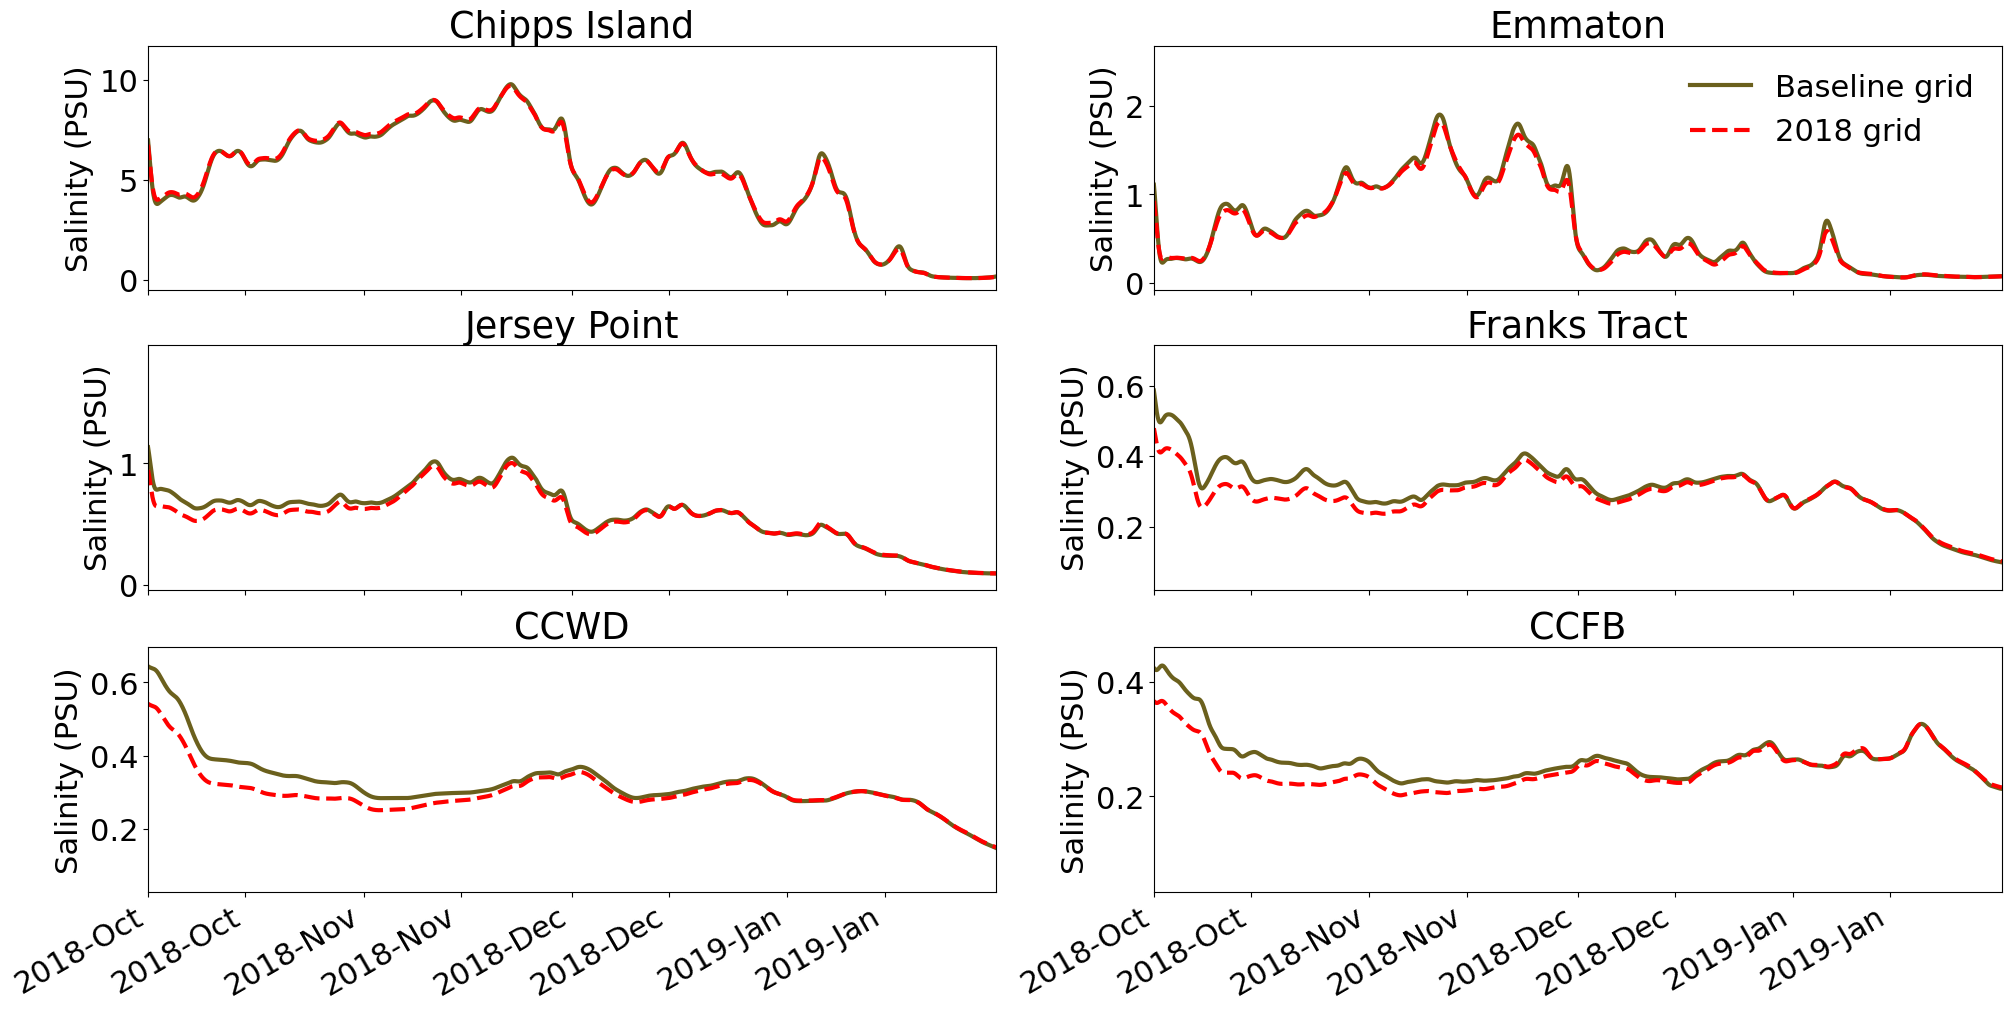

In [19]:
#station_indices=[226,22,12,168,6,203] 
#from Lily:
station_indices=[23,9,22,203,105,60]
fig, ax = plt.subplots(3,2,figsize=(20,10),sharex=True,layout='constrained',label='compliance')
mpl.rcParams.update({'font.size': 22})
# ax.grid(alpha=0.5)
for idx in station_indices:
    if idx == 23:
        s=(0,0)
        tstring='Chipps Island'
        #ax[s].hlines(y=1.3775, xmin=pd.to_datetime("2019-2-1"), xmax=pd.to_datetime("2019-6-1"),color='k',linestyle='--',label='compliance')
        #ax[s].hlines(y=1.3775, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-6-1"),color='k',linestyle='--',label='compliance')
    if idx == 9:
        s=(0,1)
        tstring='Emmaton'
        #ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2019-4-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
        #ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
    if idx == 22:
        s=(1,0)
        tstring='Jersey Point'
        #ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2019-4-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
        #ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
    if idx == 203:
        s=(1,1)
        tstring='Franks Tract'
    if idx == 105:
        s=(2,0)
        tstring='CCWD'
        #ax[s].hlines(y=0.3255, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--',label='compliance')
    if idx == 60:
        s=(2,1)
        tstring='CCFB'
        #ax[s].hlines(y=0.3387, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--',label='compliance')
    
    print(s)
    values1 = run27[str(idx)]
    values2 = run30[str(idx)]
       
    ax[s].plot(values1, label = 'Baseline grid', linewidth=3, alpha =1, color=cmocean.cm.tarn(1/6))
    ax[s].plot(values2, label = '2018 grid', linewidth=3, alpha =1,linestyle='--', color='r')
    #ax[s].set_title(stations[idx-1]) #this list is zero indexed
    ax[s].set_title(tstring)
    #ax[s].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
    ax[s].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-1-31"))
    ax[s].set_ylabel('Salinity (PSU)')
    # Rotates and right-aligns the x labels so they don't crowd each other.

    
#ax.plot(data1.time,np.ones_like(values1)*std,linewidth=2, alpha =0.7,linestyle='--',color='k',label='Compliance')

#leg = ax.legend()
#print(ax)
#ax.set_xlim(data1.time.iloc[52000], data3.time.iloc[-1]) #July 1 to end
# ax.grid(which='major', color='b', linestyle='-')
#ax.set_title("Salinity from baroclinic run")
#ax[0,1].xaxis.set_major_formatter(mdates.DateFormatter('%b-%d-%Y'))
ax[0,1].legend(frameon=False)
ax[2,0].xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax[2,0].xaxis.get_major_locator()))
ax[2,0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
    # Rotates and right-aligns the x labels so they don't crowd each other.
for label in ax[2,0].get_xticklabels(which='major'):
    label.set(rotation=30, horizontalalignment='right')
ax[2,1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax[2,1].xaxis.get_major_locator()))
ax[2,1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
    # Rotates and right-aligns the x labels so they don't crowd each other.
for label in ax[2,1].get_xticklabels(which='major'):
    label.set(rotation=30, horizontalalignment='right')

plt.show()
#fig.savefig('six_stations_grid_comparison.png')

In [20]:
# for each station max and mean difference

In [21]:
station_indices=[23,9,22,203,105,60]
# ax.grid(alpha=0.5)
for idx in station_indices:
    if idx == 23:
        s=(0,0)
        tstring='Chipps Island'
        #ax[s].hlines(y=1.3775, xmin=pd.to_datetime("2019-2-1"), xmax=pd.to_datetime("2019-6-1"),color='k',linestyle='--',label='compliance')
        #ax[s].hlines(y=1.3775, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-6-1"),color='k',linestyle='--',label='compliance')
    if idx == 9:
        s=(0,1)
        tstring='Emmaton'
        #ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2019-4-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
        #ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
    if idx == 22:
        s=(1,0)
        tstring='Jersey Point'
        #ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2019-4-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
        #ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
    if idx == 203:
        s=(1,1)
        tstring='Franks Tract'
    if idx == 105:
        s=(2,0)
        tstring='CCWD'
        #ax[s].hlines(y=0.3255, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--',label='compliance')
    if idx == 60:
        s=(2,1)
        tstring='CCFB'
        #ax[s].hlines(y=0.3387, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--',label='compliance')
    
    print(tstring)
    values1 = run27[str(idx)]
    values2 = run30[str(idx)]
    griddif = (values1-values2)[pd.to_datetime("2018-10-1"):pd.to_datetime("2019-1-31")]
    #add percent difference
    perdif = griddif/((values1+values2)*0.5) #percent difference 
    
    #print('max difference is '+ str(griddif.max())+' occuring on')
    #print(griddif.idxmax())
    print('max percent difference is '+ str(perdif.max())+' occuring on')
    print(perdif.idxmax())
    
    #print('min difference is '+ str(griddif.min())+' occuring on')
   # print(griddif.idxmin())
    print('min percent difference is '+ str(perdif.min())+' occuring on')
    print(perdif.idxmin())
    #print('mean difference is '+str(griddif.mean()))
    print('mean percent difference is '+str(perdif.mean()))

Chipps Island
max percent difference is 0.08790590557045772 occuring on
2019-01-17 10:45:00
min percent difference is -0.05387592572441543 occuring on
2018-10-02 05:15:00
mean percent difference is -0.003113889042535093
Emmaton
max percent difference is 0.18342524723484818 occuring on
2019-01-05 17:15:00
min percent difference is -0.18028217164282986 occuring on
2018-10-02 05:15:00
mean percent difference is 0.02963367546719051
Jersey Point
max percent difference is 0.19705524998931082 occuring on
2018-10-03 01:45:00
min percent difference is -0.030654981141079334 occuring on
2019-01-05 12:45:00
mean percent difference is 0.04309115897454428
Franks Tract
max percent difference is 0.22265327210419864 occuring on
2018-10-05 18:15:00
min percent difference is -0.02846883195056458 occuring on
2019-01-29 23:00:00
mean percent difference is 0.06404614058792846
CCWD
max percent difference is 0.19312185963994416 occuring on
2018-10-15 05:15:00
min percent difference is -0.011508386203778078 oc

In [22]:
station_indices=[23,9,22,203,105,60]
# ax.grid(alpha=0.5)
for idx in station_indices:
    if idx == 23:
        s=(0,0)
        tstring='Chipps Island'
        #ax[s].hlines(y=1.3775, xmin=pd.to_datetime("2019-2-1"), xmax=pd.to_datetime("2019-6-1"),color='k',linestyle='--',label='compliance')
        #ax[s].hlines(y=1.3775, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-6-1"),color='k',linestyle='--',label='compliance')
    if idx == 9:
        s=(0,1)
        tstring='Emmaton'
        #ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2019-4-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
        #ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
    if idx == 22:
        s=(1,0)
        tstring='Jersey Point'
        #ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2019-4-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
        #ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
    if idx == 203:
        s=(1,1)
        tstring='Franks Tract'
    if idx == 105:
        s=(2,0)
        tstring='CCWD'
        #ax[s].hlines(y=0.3255, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--',label='compliance')
    if idx == 60:
        s=(2,1)
        tstring='CCFB'
        #ax[s].hlines(y=0.3387, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--',label='compliance')
    
    print(tstring)
    values1 = run27[str(idx)]
    values2 = run30[str(idx)]
    griddif = (values1-values2)[pd.to_datetime("2018-10-1"):pd.to_datetime("2019-1-31")]
    
    print('max difference is '+ str(griddif.max())+' occuring on')
    print(griddif.idxmax())

    print('min difference is '+ str(griddif.min())+' occuring on')
    print(griddif.idxmin())
    
    print('mean difference is '+str(griddif.mean()))


Chipps Island
max difference is 0.21507639392639444 occuring on
2018-10-01 00:00:00
min difference is -0.21169654115744097 occuring on
2018-10-02 04:45:00
mean difference is -0.02671312833819867
Emmaton
max difference is 0.18032845180291435 occuring on
2018-10-01 00:00:00
min difference is -0.04554215843369941 occuring on
2018-10-02 05:15:00
mean difference is 0.023095913132515057
Jersey Point
max difference is 0.1864410062012566 occuring on
2018-10-01 00:00:00
min difference is -0.015214891843842115 occuring on
2019-01-05 14:30:00
mean difference is 0.03051867360752009
Franks Tract
max difference is 0.10638350661619067 occuring on
2018-10-01 00:00:00
min difference is -0.004228690860244799 occuring on
2019-01-22 14:45:00
mean difference is 0.021633832338157865
CCWD
max difference is 0.10244348205798359 occuring on
2018-10-01 12:15:00
min difference is -0.0017224490625298017 occuring on
2019-01-31 00:00:00
mean difference is 0.023650361935807725
CCFB
max difference is 0.062164640668605

In [ ]:
# what are the diffs at this timestep jan8 12:30


In [ ]:
stadays

In [ ]:
comp1.index.month.values

In [ ]:
np.unique(comp1.index.month.values)

In [ ]:
values2['month']=values2.index.month
values2

In [ ]:
#values1[pd.to_datetime("2018-10-1"):pd.to_datetime("2019-9-30")]

# below here not used

In [ ]:
# #function comes from schimpy metricsplot.py script https://github.com/CADWRDeltaModeling/schimpy/blob/master/schimpy/metricsplot.py
# from vtools.data.vtime import days, hours, minutes
# from vtools.functions.filter import cosine_lanczos
# def filter_timeseries(tss, cutoff_period=hours(40)):
#     filtered = []
#     ts=tss #try removing the loop for now
#     if ts is None:
#         filtered.append(None)
#     else:
#         #print(ts)
#         ts_filtered = cosine_lanczos(ts, cutoff_period=cutoff_period)
#         ts_filtered.filtered = 'cosine_lanczos'

#     return ts_filtered

In [ ]:
# import re 
# file="/expanse/lustre/scratch/jisrael/temp_project/run_schism/run_28/station.in"
# station_id =[]
# with open(file) as f:
#     f.readline()
#     for station in range(int(f.readline())):
#         line = f.readline()
#         if '!' in line:
#             station_id.append(line.split('!')[-1])
#         else:
#             station_id.append(None)
# # print(station_id)

# print(len(station_id))

# stations = []
# for sublist in station_id:
#     match = re.search(r'"(.*?)"', sublist)
#     if match:
#         stations.append(match.group(1).strip())
#     else :
#         stations.append(sublist.replace("\n", "").strip())
# print(len(set(stations)))


# for i, station in enumerate(stations):
#     print("%d == %s" % (i,station))

In [ ]:
# def clean_staout(path2staout,path2stations,starttime,filt=True):
#     #where path2staout is the path to the station text file you want to read
#     #path2stations in the station file used to log this file
#     #starttime is a string of the form "09-10-2020 00:00:00"
#     #if filt=True the dataset is filtered
#     station_id =[]
#     with open(path2stations) as f:
#         f.readline()
#         for station in range(int(f.readline())):
#             line = f.readline()
#             if '!' in line:
#                 station_id.append(line.split('!')[-1])
#             else:
#                 station_id.append(None)
#     # print(station_id)
    
#     print(len(station_id))
    
#     stations = []
#     for sublist in station_id:
#         match = re.search(r'"(.*?)"', sublist)
#         if match:
#             stations.append(match.group(1).strip())
#         else :
#             stations.append(sublist.replace("\n", "").strip())
#     print(len(set(stations)))

#     # for i, station in enumerate(stations):
#     #     print("%d == %s" % (i,station))
#     columns = ['time']
#     stations_no = [str(i) for i in range(len(stations))]
#     columns = columns + stations_no
#     df = pd.read_csv(path2staout, sep=r'\s+', names=columns,dtype=np.float32)
#     #fill nans
#     df = df.fillna(-9999)
#     timedelta = [pd.Timedelta(i, unit = 's') for i in df.time]
#     timestamp = [pd.to_datetime(starttime) + i for i in timedelta]
#     df["time"] = timestamp
#     if filt==True:
#         df.set_index("time",inplace=True)
#         df['time'] = timestamp
#         df=df.asfreq('900s')
#         df_filt=filter_timeseries(df)
#         return df
#     else:
#         return df

In [ ]:
# # 1:elev,2:air pressure,3:wind_x,4:wind_y,5:temp,6:salt,7:u,8:v,9:w
# file27="/expanse/lustre/scratch/jisrael/temp_project/run_schism/run_27/station_files/run_27_salinity_padded.txt"
# file28="/expanse/lustre/scratch/jisrael/temp_project/run_schism/run_28/outputs/staout_6"
# file29="/expanse/lustre/scratch/jisrael/temp_project/run_schism/run_29/outputs/staout_6"
# stationfile="/expanse/lustre/scratch/jisrael/temp_project/run_schism/run_28/station.in"
# runstarttime="08-14-2018 00:00:00"

In [ ]:
# #run27=clean_staout(file27,stationfile,runstarttime)
# run28=clean_staout(file28,stationfile,runstarttime,filt=True)
# #run29=clean_staout(file29,stationfile,runstarttime)
# run28

In [ ]:
# run28_raw=clean_staout(file28,stationfile,runstarttime,filt=False)

In [ ]:
# run28_raw.set_index("time",inplace=True)
# run28_raw

In [ ]:
# run28_raw=run28_raw.asfreq('15min')

In [ ]:
# run28_filt=filter_timeseries(run28_raw)

In [ ]:
# need to replace the "nan" values bc the cosine filter is not going to tolerate them as strings